# Library Inclusion and Utilities

In [1]:
import pandas as pd
import numpy as np
import itables.options as opt
from itables import show
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
from pathlib import Path
import matplotlib.pyplot as plt
import sys

sys.path.append("../RQ1")   # path to the folder containing GC.py
from GC import * 

In [2]:
news_df = pd.read_csv('../TopicMatchings/news_with_topics.csv')
# pubmed_df = pd.read_csv('../TopicMatchings/pubmed_with_topics.csv')
reddit_df = pd.read_csv('../TopicMatchings/reddit_with_topics.csv')
youtube_df = pd.read_csv('../TopicMatchings/youtube_final_data.csv')
new_pubmed_df = pd.read_csv("../../../Publications/PubMed/Data_Pubmed/pubmed_new_articles.csv")

# Data Preparation

Convert youtube columns to numeric

In [3]:
# robust numeric parse (coerces bad values to NaN)
for c in ['likes','comments_count','views']:
    youtube_df[c] = (pd.to_numeric(
        youtube_df[c].astype(str).str.replace(',', ''), errors='coerce'
    ))

Create an engagement rate column

In [4]:
youtube_df['likes'] = youtube_df['likes'].astype(float)
youtube_df['comments_count'] = youtube_df['comments_count'].astype(float)

youtube_df['engagement']=youtube_df['likes'] + youtube_df['comments_count']
youtube_df['engagement_rate'] = youtube_df['engagement'] / youtube_df['views']
youtube_df.loc[youtube_df['views'] == 0, 'engagement_rate'] = 0

Create youtube ts

In [5]:
def count_eng_rate():
    df = (youtube_df.groupby(['topic_num', 'date'])['engagement_rate'].sum().reset_index())
    df["source"] = 'Youtube'
    return df
youtube_ts = count_eng_rate()
youtube_ts.rename(columns={'engagement_rate':'count'}, inplace=True)

Rename date column

In [6]:
# rename to a common name for simplicity
news_df = news_df.rename(columns={'Publication date': 'date'})
# pubmed_df = pubmed_df.rename(columns={'pub_date': 'date'})  # adjust if different
reddit_df = reddit_df.rename(columns={'ts_utc': 'date'})

# convert all to datetime
for df in [news_df, reddit_df, youtube_df]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.floor("D")

Create an all_ts df with per-day count

In [7]:
news_ts   = topic_timeseries(news_df, "News")
# pubmed_ts = topic_timeseries(pubmed_df, "PubMed")
reddit_ts = topic_timeseries(reddit_df, "Reddit")
# youtube_ts = topic_timeseries(youtube_df, "Youtube")
new_pubmed_ts = topic_timeseries(new_pubmed_df, "PubMed")

# combine
all_ts = pd.concat([news_ts, reddit_ts, youtube_ts, new_pubmed_ts])

Map topic_num to all_ts df

In [8]:
topic_map = (
    youtube_df.groupby("topic_num")["keywords"]
    .unique()
    .apply(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
    .to_dict()
)
all_ts["topic_name"] = all_ts["topic_num"].map(topic_map)

In [11]:
weekly = group_by_date(all_ts, 'W')

In [12]:
weekly[weekly['source']=='Youtube']

,topic_num,topic_name,source,week_mon,count
1035,0.0,centenarians,Youtube,2010-01-04,0.005226
1036,0.0,centenarians,Youtube,2010-01-11,0.010479
1037,0.0,centenarians,Youtube,2010-01-18,0.003547
1038,0.0,centenarians,Youtube,2010-02-08,0.001426
1039,0.0,centenarians,Youtube,2010-02-22,0.003155
...,...,...,...,...,...
28814,16.0,modafinil and nootropics,Youtube,2025-09-29,0.257397
28815,16.0,modafinil and nootropics,Youtube,2025-10-06,0.278202
28816,16.0,modafinil and nootropics,Youtube,2025-10-13,0.326595
28817,16.0,modafinil and nootropics,Youtube,2025-10-20,0.256259


In [13]:
new_pubmed_df

,pmid,title,abstract,journal,year,pub_date,mesh_terms,source,topic,period,topic_num,date
0,33297486,"The Gut Microbiome, Aging, and Longevity: A Sy...",Aging is determined by complex interactions am...,Nutrients,2020.0,"{'Year': '2020', 'Month': 'Dec', 'Day': '07'}","Adult; Aged; Aged, 80 and over; Aging; Amino A...",PubMed,Centenarians,15-year data,0.0,2020-12-07
1,37495893,The multifaceted benefits of walking for healt...,"Physical activity, including walking, has nume...",GeroScience,2023.0,"{'Year': '2023', 'Month': 'Dec'}","Aged, 80 and over; Humans; Aged; Diabetes Mell...",PubMed,Centenarians,15-year data,0.0,2023-12-01
2,37726432,Blood biomarker profiles and exceptional longe...,Comparing biomarker profiles measured at simil...,GeroScience,2024.0,"{'Year': '2024', 'Month': 'Apr'}","Aged, 80 and over; Female; Humans; Aged; Male;...",PubMed,Centenarians,15-year data,0.0,2024-04-01
3,39504246,"Metabolite signatures of chronological age, ag...",Metabolites that mark aging are not fully know...,Cell reports,2024.0,"{'Year': '2024', 'Month': 'Nov', 'Day': '26'}",Longevity; Humans; Aging; Aged; Male; Female; ...,PubMed,Centenarians,15-year data,0.0,2024-11-26
4,38900423,Healthy Lifestyle and the Likelihood of Becomi...,Previous studies have reported that lifestyle ...,JAMA network open,2024.0,"{'Year': '2024', 'Month': 'Jun', 'Day': '03'}","Humans; Male; Female; Healthy Lifestyle; Aged,...",PubMed,Centenarians,15-year data,0.0,2024-06-03
...,...,...,...,...,...,...,...,...,...,...,...,...
21582,23785170,"Small-animal PET with a σ-ligand, 11C-SA4503, ...",Pituitary tumors are often detected only after...,Journal of nuclear medicine : official publica...,2013.0,"{'Year': '2013', 'Month': 'Aug'}",Aging; Animals; Brain; Kinetics; Ligands; Male...,PubMed,modafinil_nootropic,15-year data,16.0,2013-08-01
21583,21345628,Age-related differences in metabolites in the ...,To study age-related metabolic changes in N-ac...,European journal of radiology,2012.0,"{'Year': '2012', 'Month': 'Mar'}",Adolescent; Adult; Age Factors; Aged; Aging; A...,PubMed,modafinil_nootropic,15-year data,16.0,2012-03-01
21584,32397609,Hydrolyzed Chicken Extract (ProBeptigen<sup>®<...,Cognitive decline is an important issue of glo...,Nutrients,2020.0,"{'Year': '2020', 'Month': 'May', 'Day': '10'}",Adult; Aged; Animals; Anti-Inflammatory Agents...,PubMed,modafinil_nootropic,15-year data,16.0,2020-05-10
21585,30877834,[The influence of self-massage combined with d...,It is shown that the two-week use of self-mass...,Advances in gerontology = Uspekhi gerontologii,2018.0,{'Year': '2018'},Aged; Dipeptides; Humans; Massage; Professiona...,PubMed,modafinil_nootropic,15-year data,16.0,2018-01-01


# Solution

In [22]:
youtube_df.groupby('topic_num')['keywords'].unique()

topic_num
0                         [centenarians]
1     [cellular senescence & senolytics]
2                     [telomere biology]
3              [rapamycin and sirolimus]
4                            [metformin]
5               [dementia and alzheimer]
6         [exercise & physical activity]
7          [diabetes & glycemic control]
8                       [gut microbiome]
9           [epigenetic and methylation]
10            [mitochondria & mitophagy]
11                            [sirtuins]
12                           [autophagy]
13              [cardiovascular disease]
14                             [obesity]
15                              [cancer]
16            [modafinil and nootropics]
Name: keywords, dtype: object

In [23]:
topic_map = {
    0: "centenarians",
    1: "cellular senescence & senolytics",
    2: "telomere biology",
    3: "rapamycin and sirolimus",
    4: "metformin",
    5: "dementia and alzheimer",
    6: "exercise & physical activity",
    7: "diabetes & glycemic control",
    8: "gut microbiome",
    9: "epigenetic and methylation",
    10: "mitochondria & mitophagy",
    11: "sirtuins",
    12: "autophagy",
    13: "cardiovascular disease",
    14: "obesity",
    15: "cancer",
    16: "modafinil and nootropics"
}

## ACF/PACF

In [14]:
def create_ts_per_source(ts: pd.DataFrame, source: str, topic_num: str = None):
    df = pd.DataFrame()
    if topic_num == None:
        trial = ts[ts['source']==source]
        trial = trial.copy().drop(columns=['source','topic_num','topic_name'])
    else:
        trial = ts[(ts['source']==source) & (ts['topic_num']==topic_num)]
        trial = trial.copy().drop(columns=['source','topic_num','topic_name'])
    
    df = trial.groupby('week_mon')['count'].sum().reset_index()

    full_weeks = pd.date_range(df["week_mon"].min(), df["week_mon"].max(), freq='W-MON')

    out = (
        df.set_index("week_mon")
          .reindex(full_weeks)
          .fillna(0.0)
          .rename_axis("week_mon")
          .reset_index()
    )

    out["count"] = out["count"]
    
    return out

In [19]:
pm_ts = create_ts_per_source(weekly, 'Reddit', 2)
pm_ts['count'].sum()

np.float64(38.07809980740184)

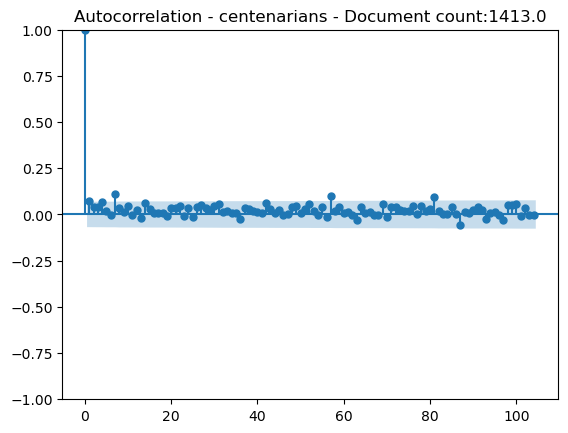

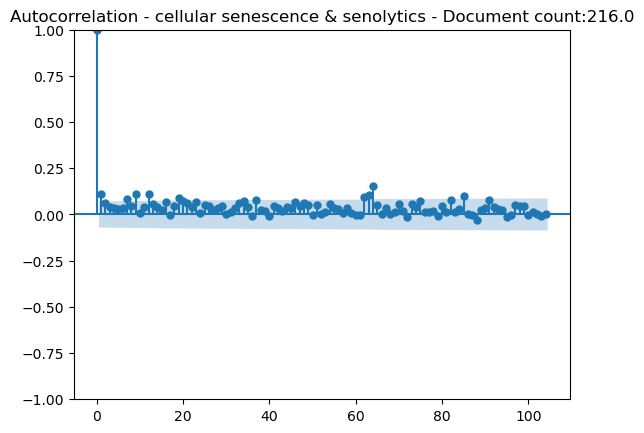

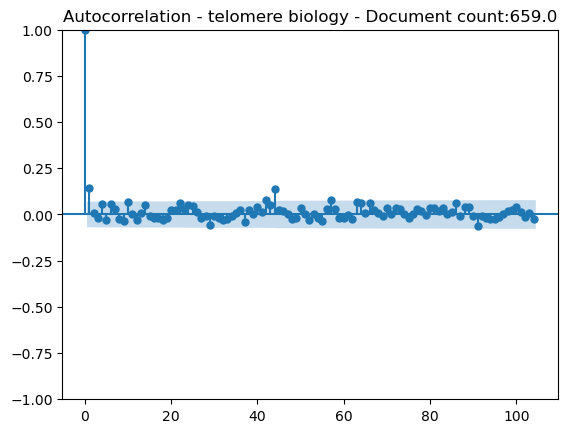

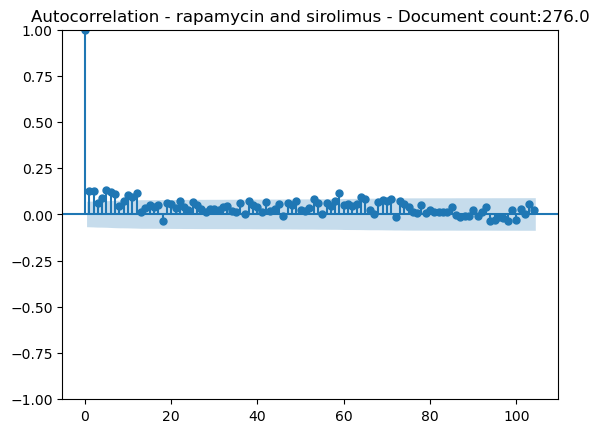

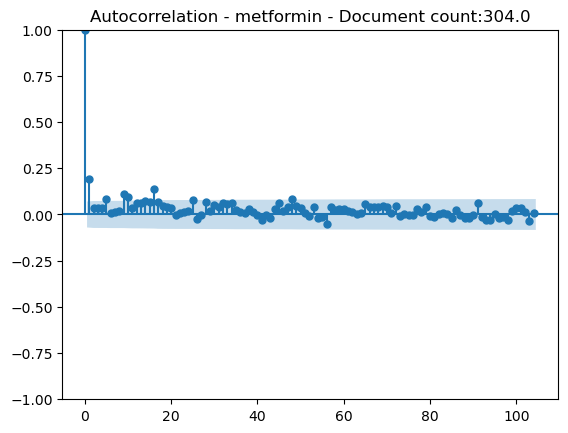

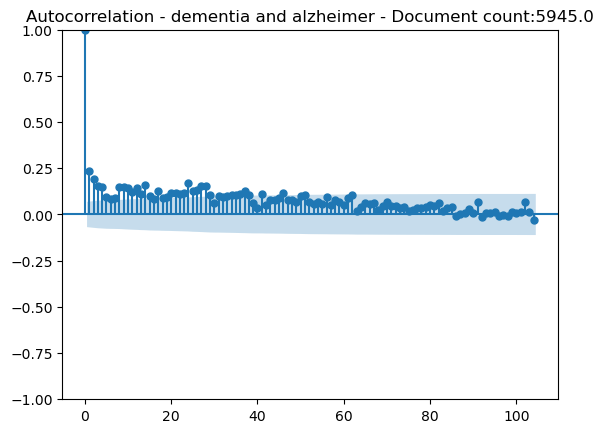

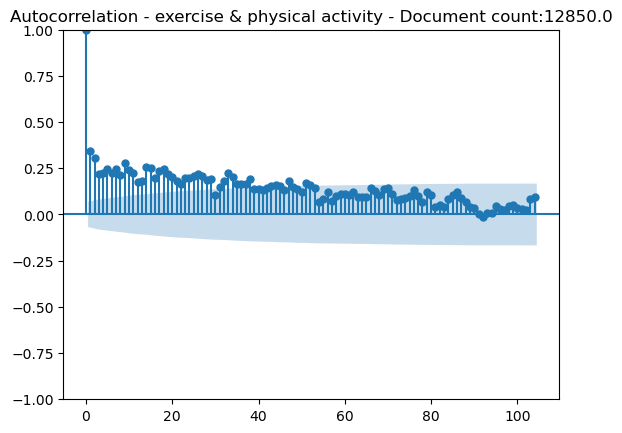

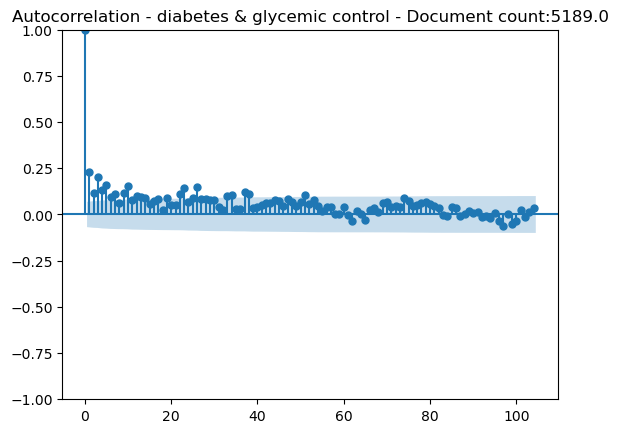

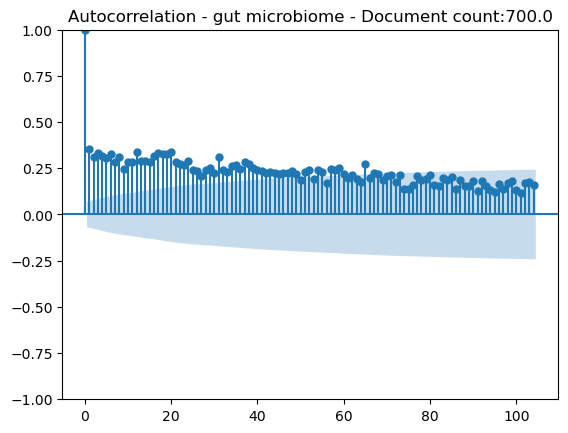

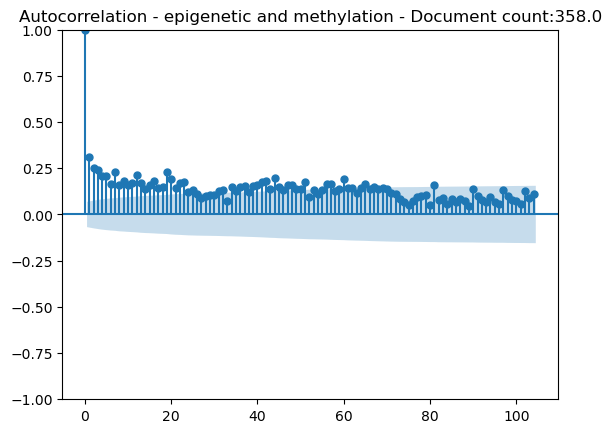

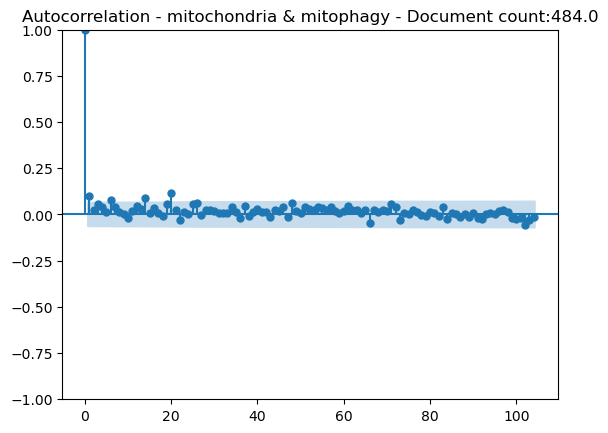

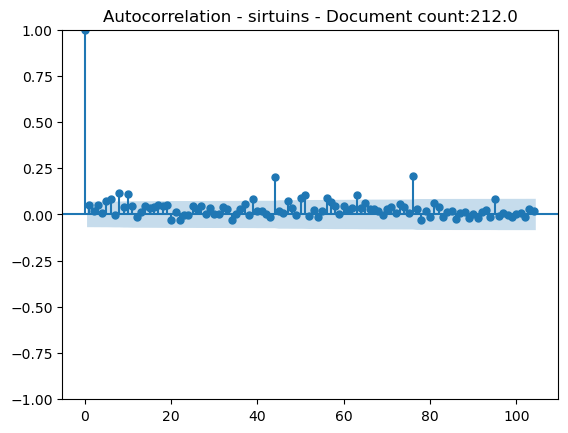

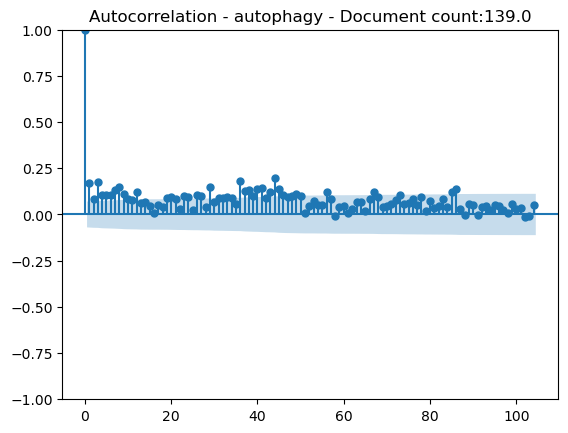

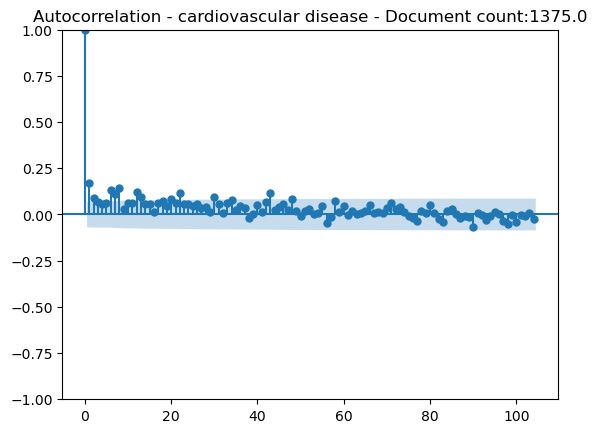

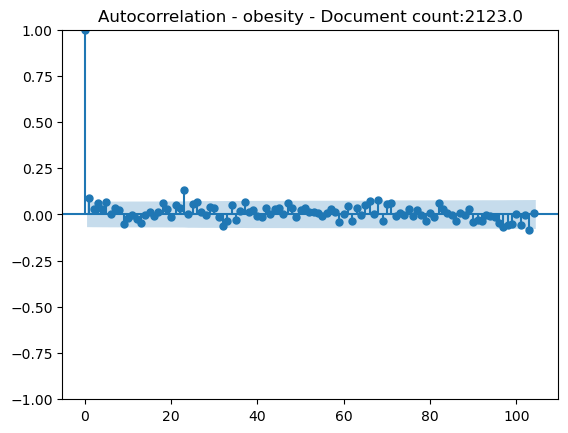

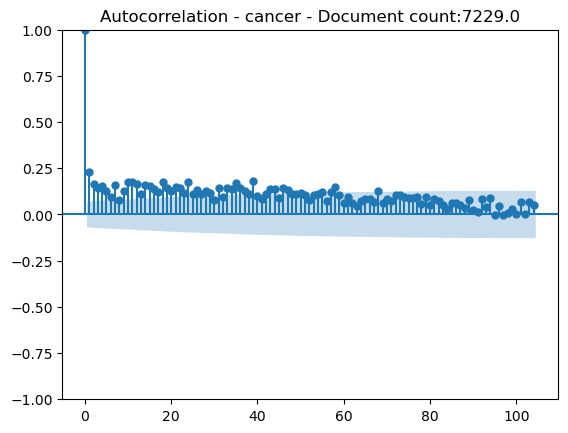

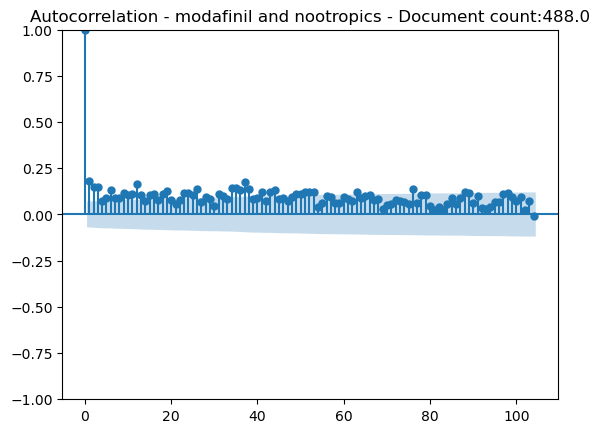

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for topic_num in range(17):
    pm_ts = create_ts_per_source(weekly, 'News', topic_num)
    plot_acf(pm_ts['count'], lags=104)  # 2 years worth of weekly lags
    plt.title(f"Autocorrelation - {topic_map[topic_num]} - Document count:{pm_ts['count'].sum()}")
    # plt.savefig("./plots/acf_youtube.png")

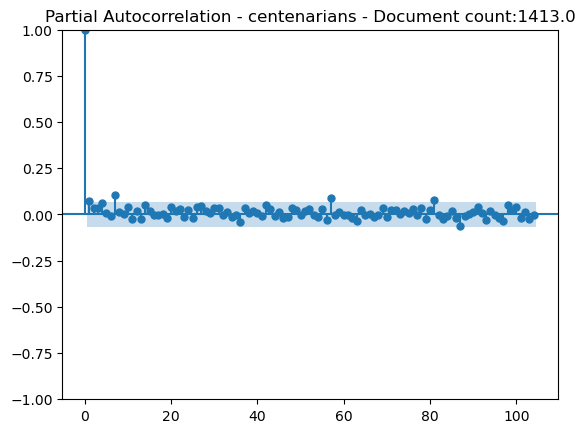

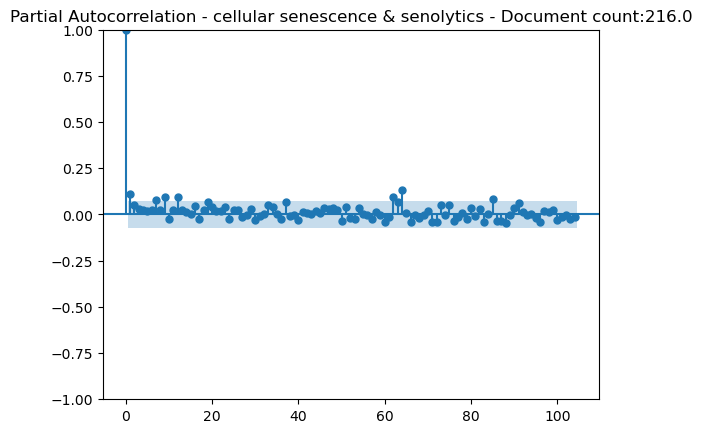

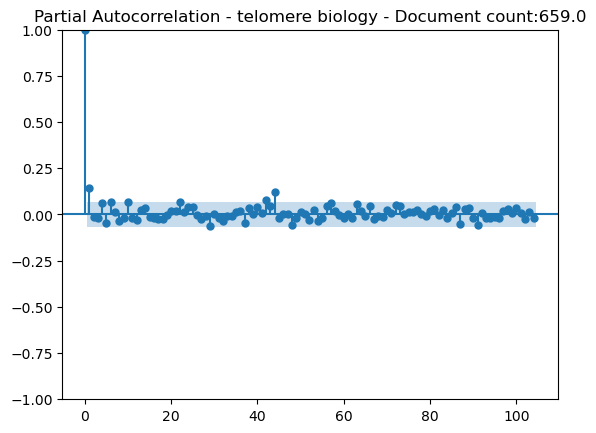

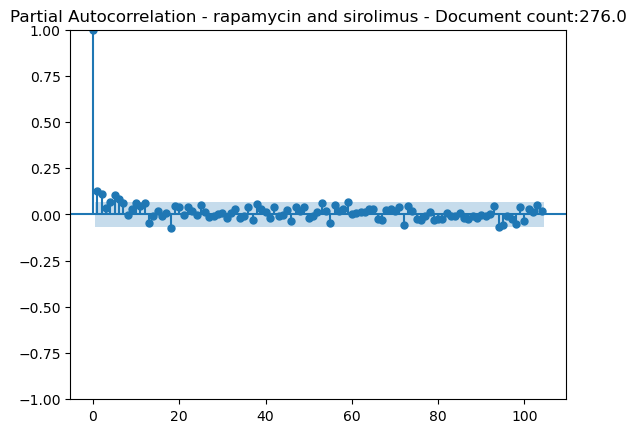

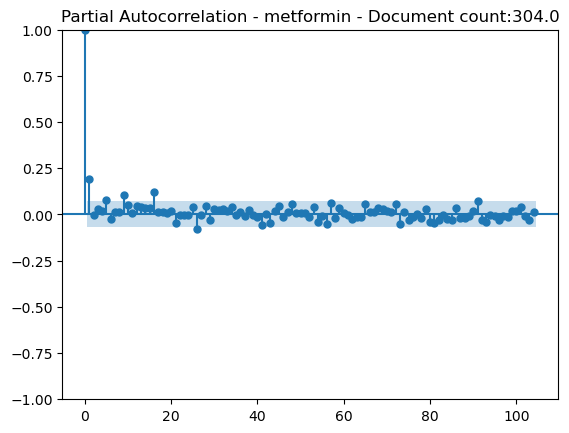

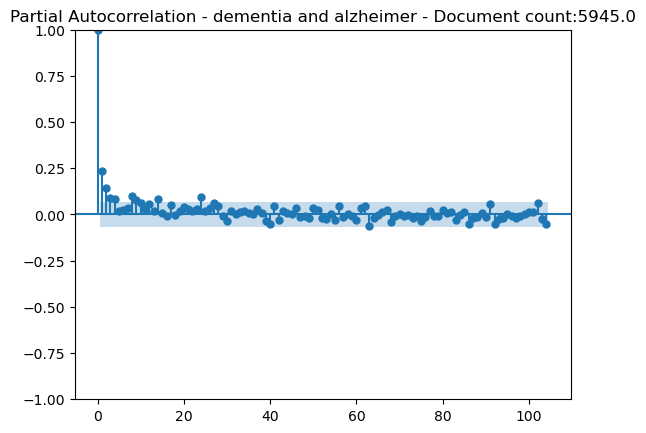

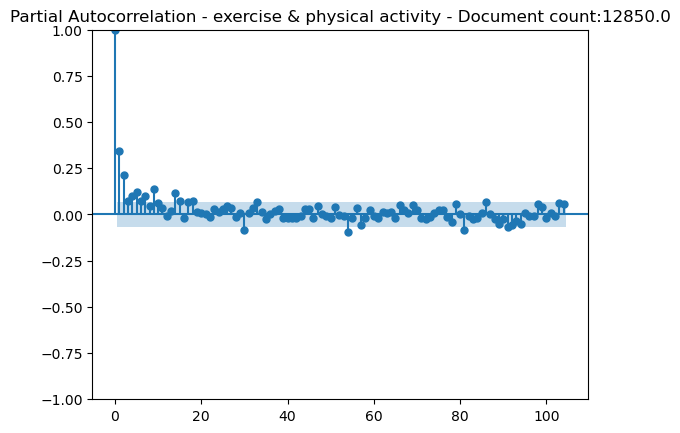

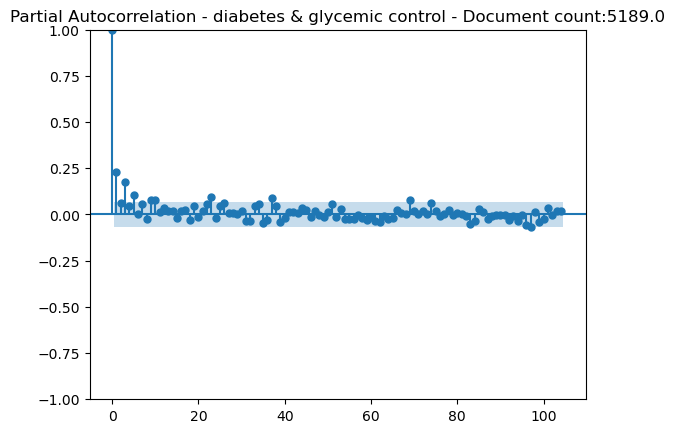

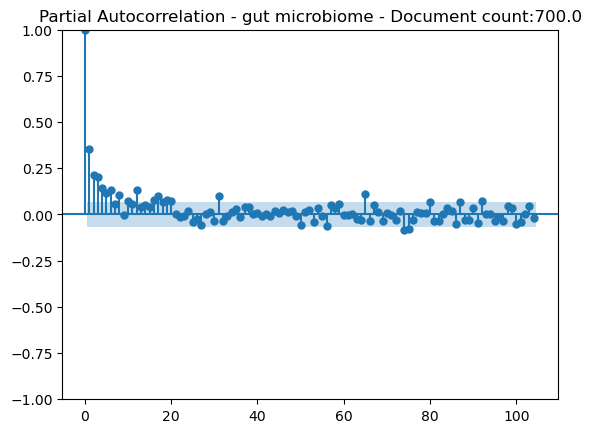

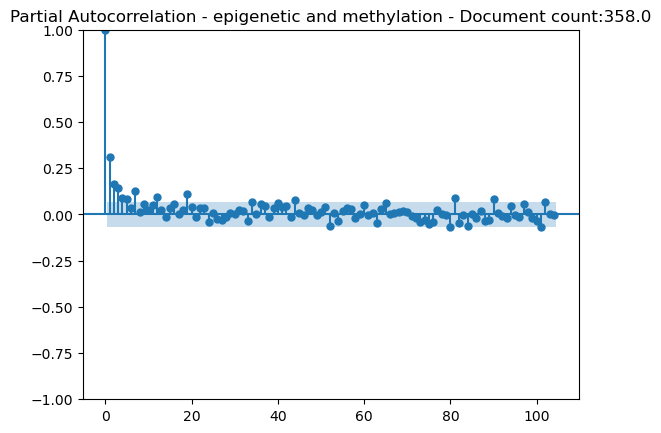

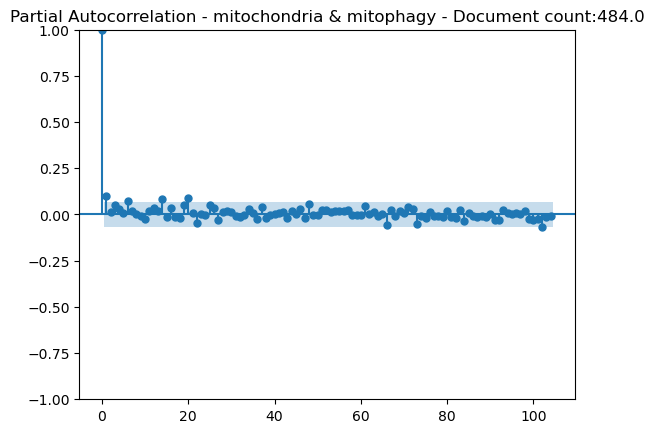

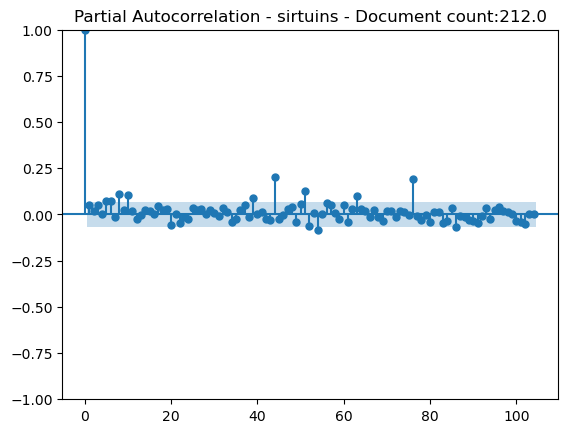

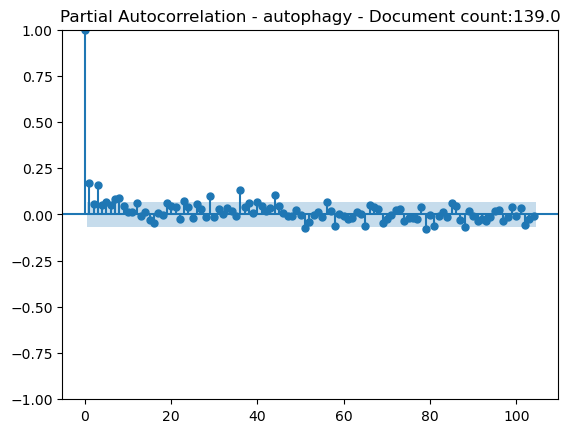

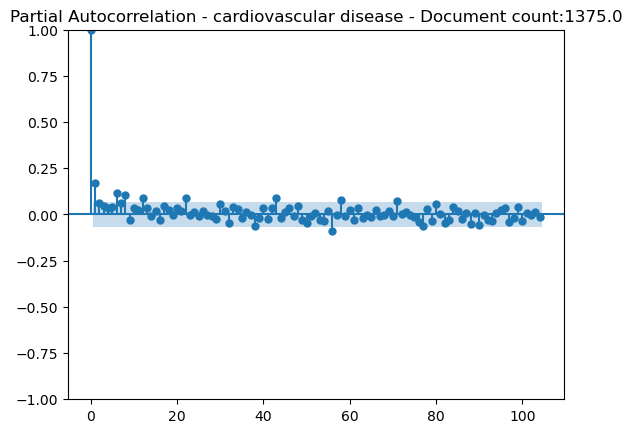

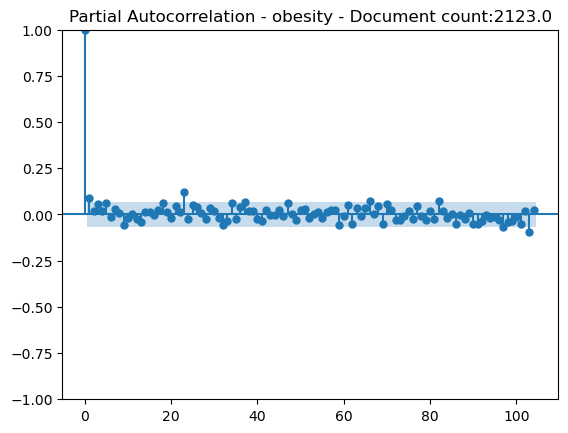

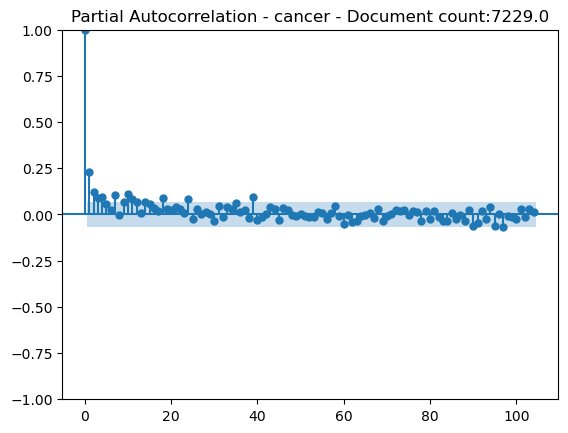

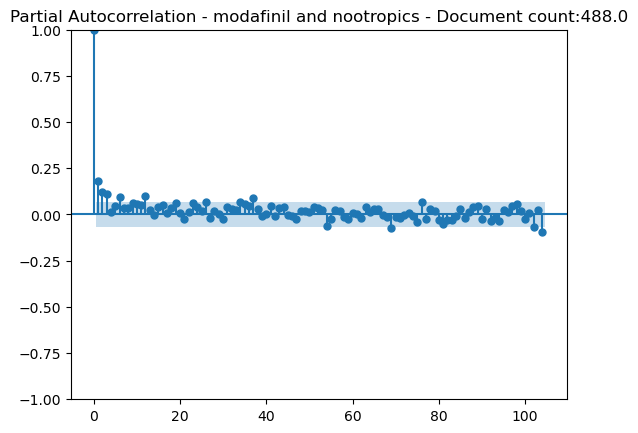

In [19]:
for topic_num in range(17):
    pm_ts = create_ts_per_source(weekly, 'News', topic_num)
    plot_pacf(pm_ts['count'], lags=104)
    plt.title(f"Partial Autocorrelation - {topic_map[topic_num]} - Document count:{pm_ts['count'].sum()}")
    plt.savefig(f"./plots/pacf_topic{topic_num}.png")

# plt.savefig("./plots/pacf_youtube.png")

## FFT/Periodogram

In [21]:
from scipy.signal import periodogram

def periodogram_seasonality(y: pd.Series, period=52, plot=True, title=None):
    """
    y: pandas Series indexed by weekly dates (or anything date-like).
       Will be reindexed to weekly Mondays and filled with 0.
    period: seasonal period in weeks (52 for annual).
    plot: whether to show a periodogram plot.
    Returns: dict with key metrics.
    """
    # # regularize to weekly frequency
    # y = y.copy()
    # y.index = pd.to_datetime(y.index)
    # y = y.asfreq("W-MON").fillna(0)

    # periodogram (frequency in cycles/week)
    freqs, power = periodogram(y.values, detrend='linear')
    if power.sum() == 0:
        return {"annual_share": 0.0, "peak_freq": np.nan, "peak_share": 0.0}

    # annual frequency ~ 1/period (e.g., 1/52)
    f_annual = 1.0 / period
    i_ann = np.argmin(np.abs(freqs - f_annual))
    annual_share = float(power[i_ann] / power.sum())

    # top peak overall (exclude freq=0)
    nz = freqs > 0
    i_peak = np.argmax(power[nz])
    peak_freq = float(freqs[nz][i_peak])            # cycles/week
    peak_share = float(power[nz][i_peak] / power.sum())
    peak_weeks = (1.0 / peak_freq) if peak_freq > 0 else np.inf

    if plot:
        plt.figure(figsize=(6,3.2))
        plt.plot(freqs, power)
        plt.axvline(f_annual, linestyle='--')  # annual marker
        plt.xlabel("Frequency (cycles per week)")
        plt.ylabel("Power")
        if title:
            plt.title(title)
        plt.tight_layout()
        # plt.savefig("./plots/peridogram_youtube.png")
        plt.show()
    
    return {
        "annual_share": annual_share,      # power at 1/52 relative to total
        "peak_freq": peak_freq,            # cycles/week
        "peak_weeks": peak_weeks,          # weeks per cycle
        "peak_share": peak_share           # max power share (excl. DC)
    }

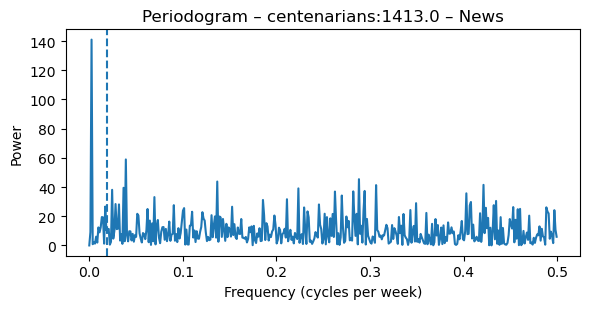

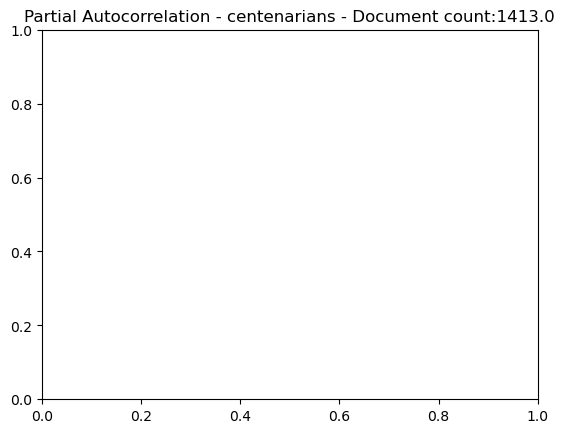

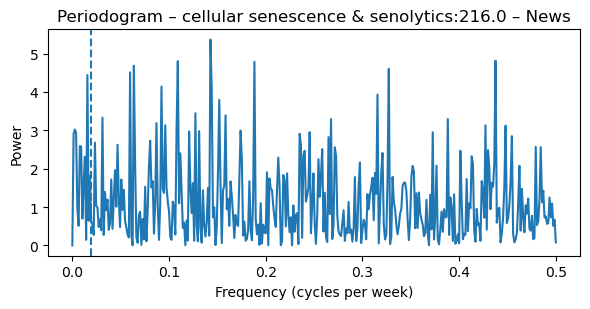

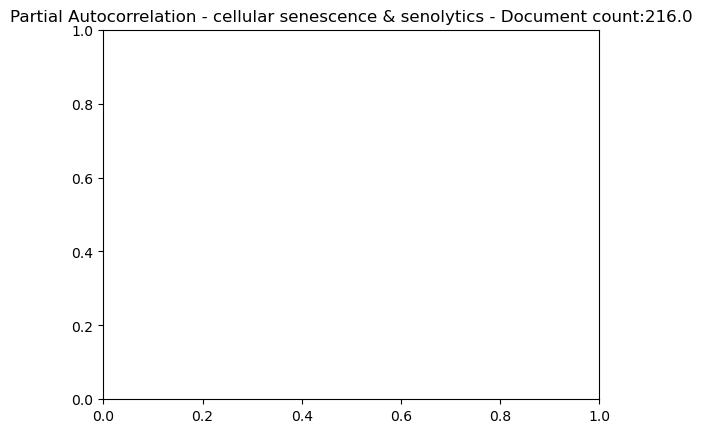

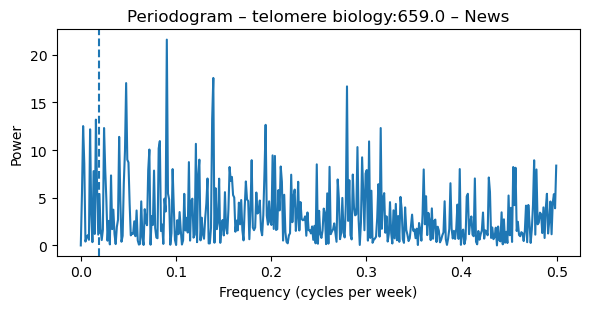

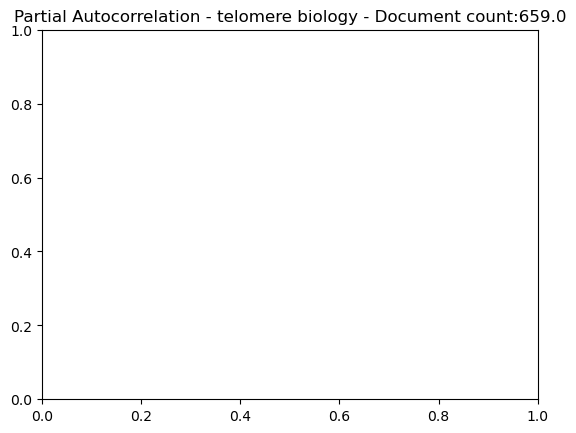

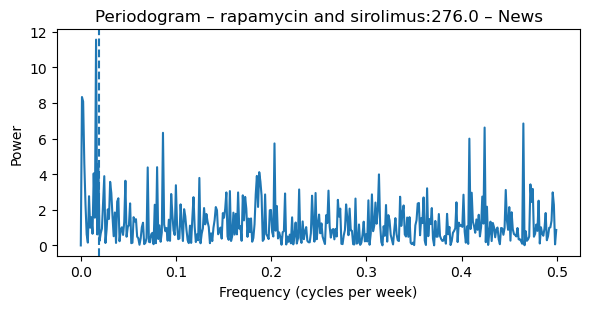

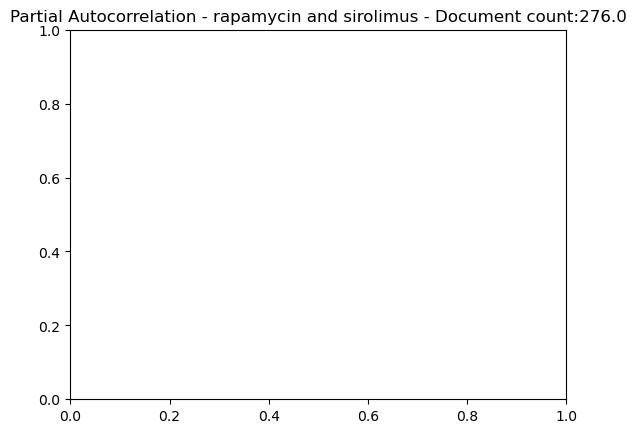

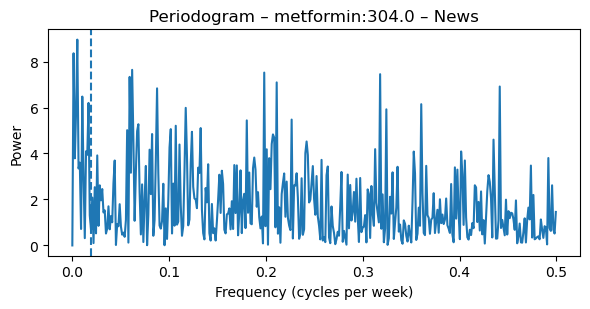

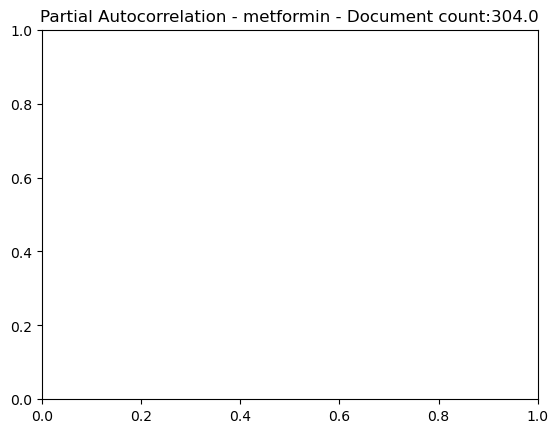

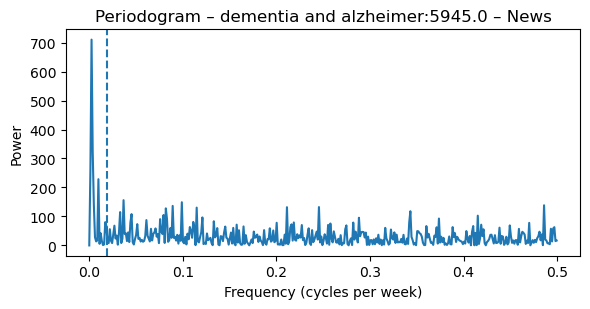

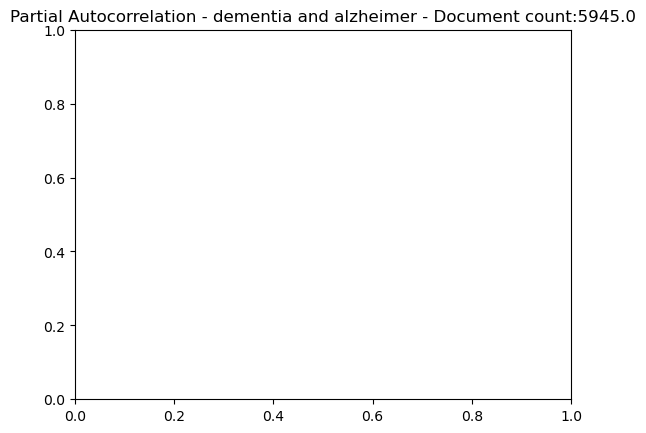

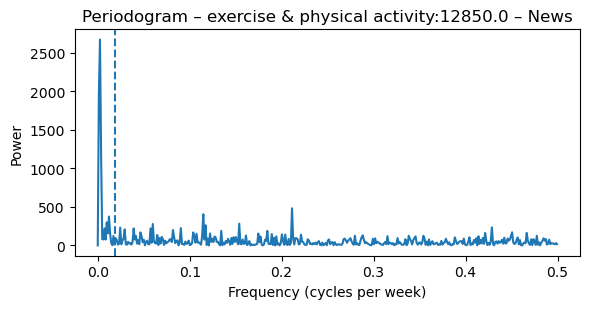

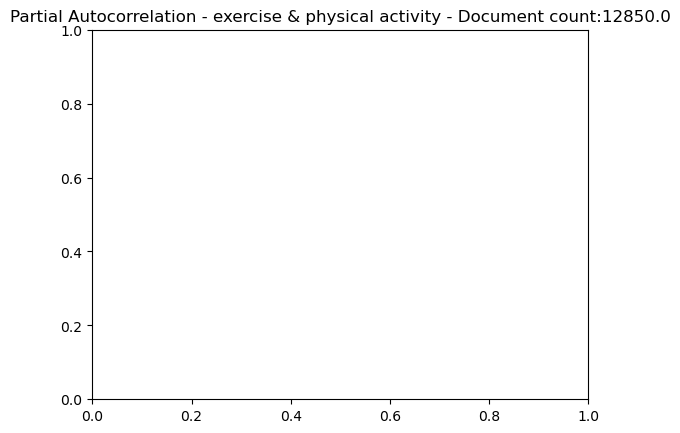

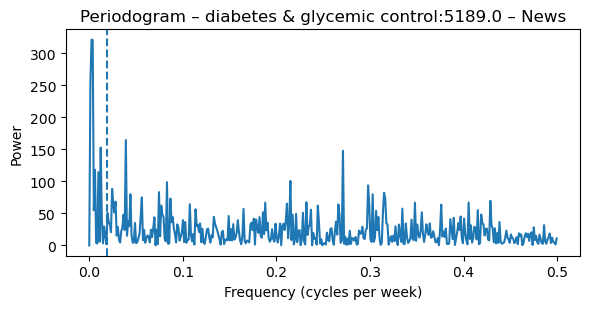

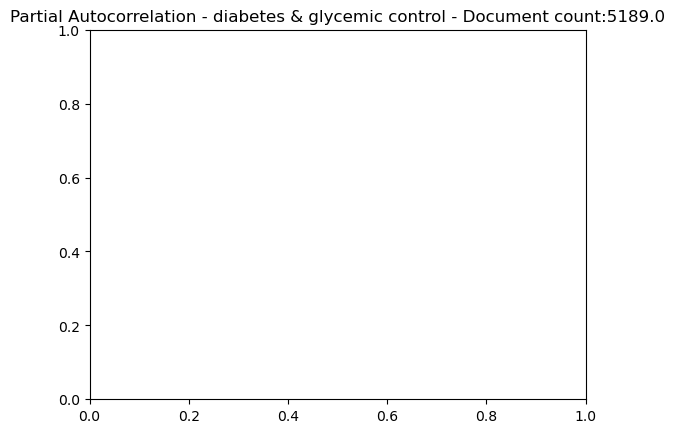

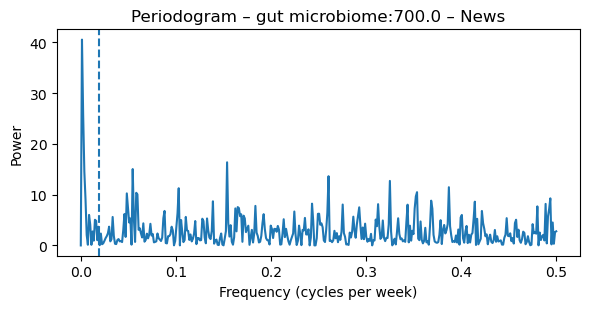

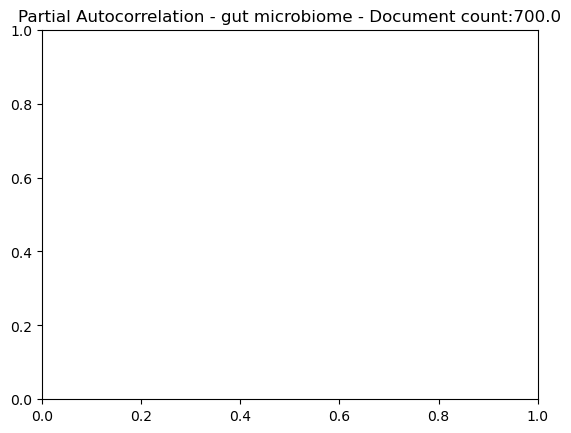

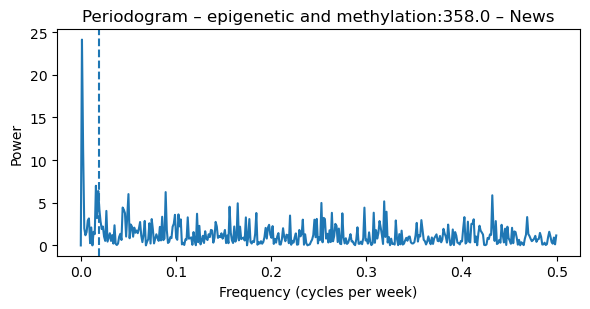

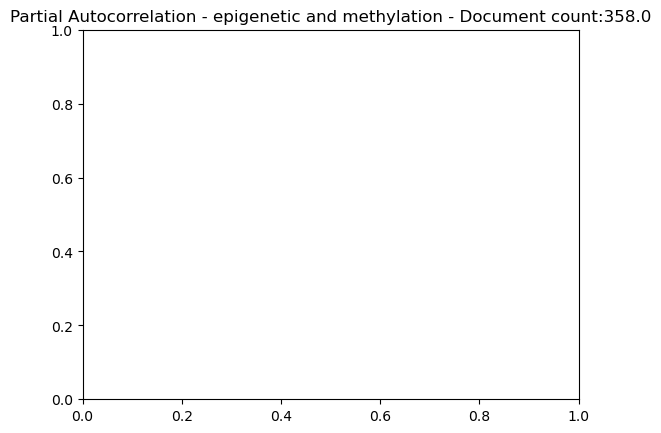

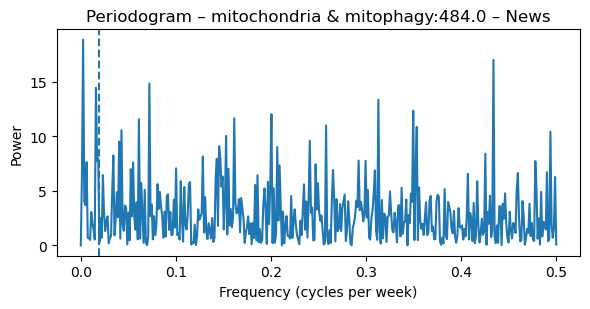

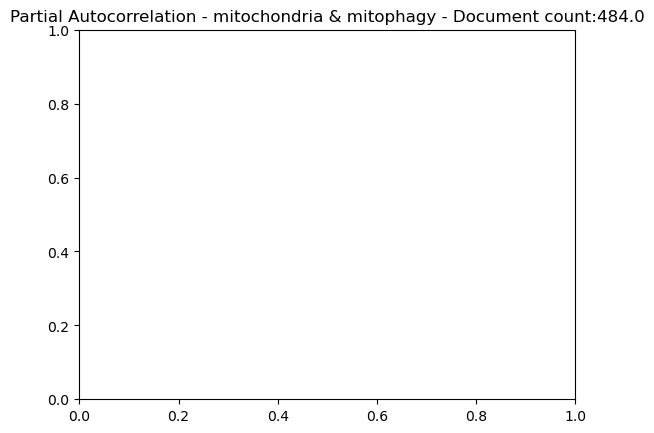

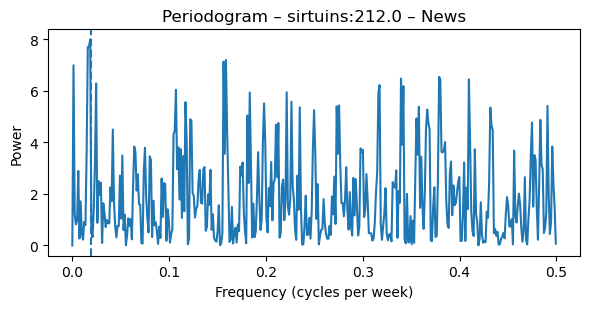

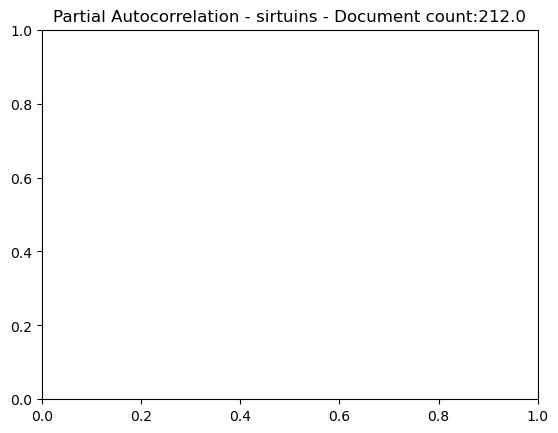

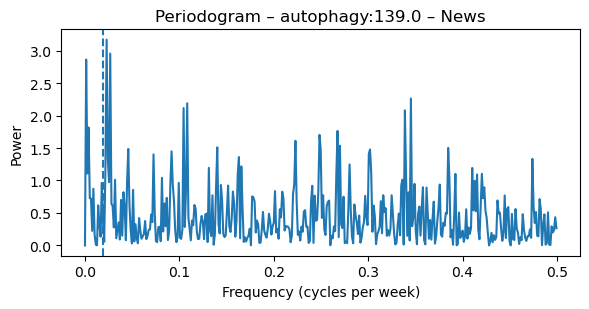

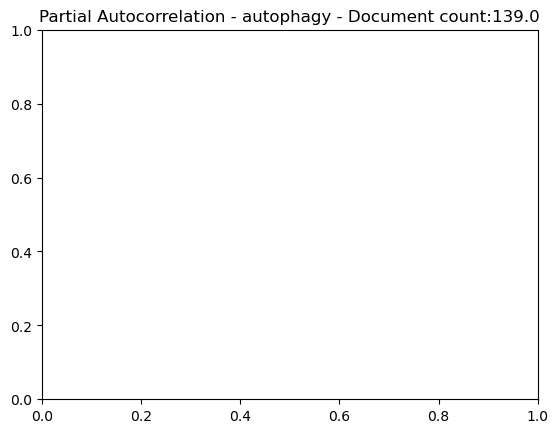

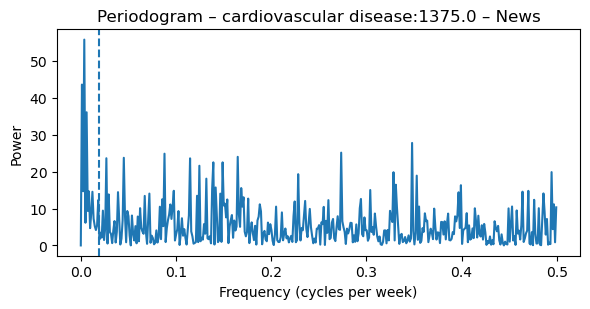

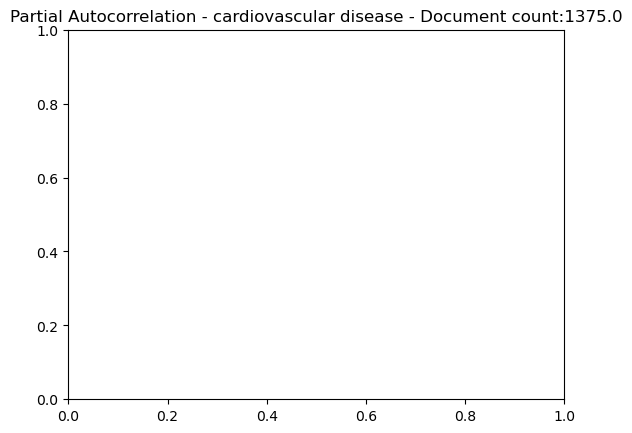

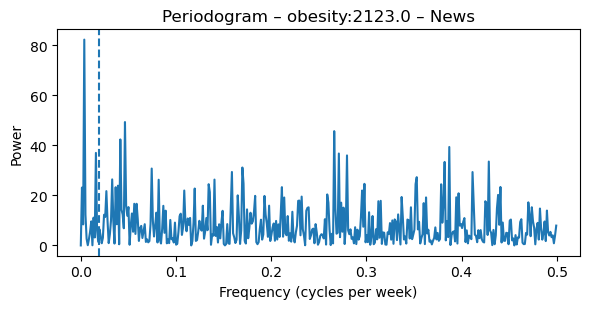

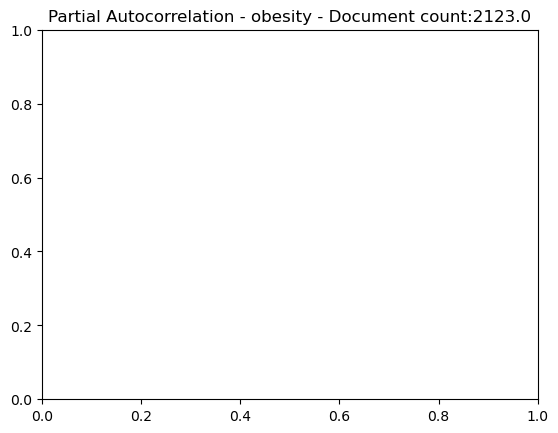

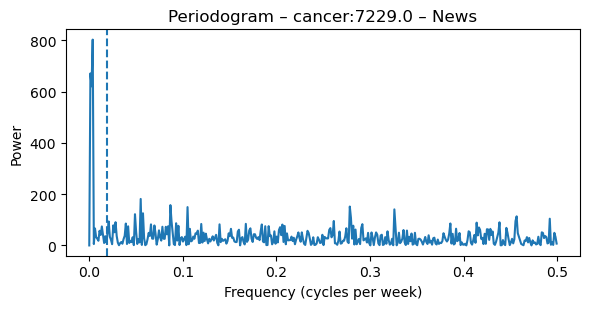

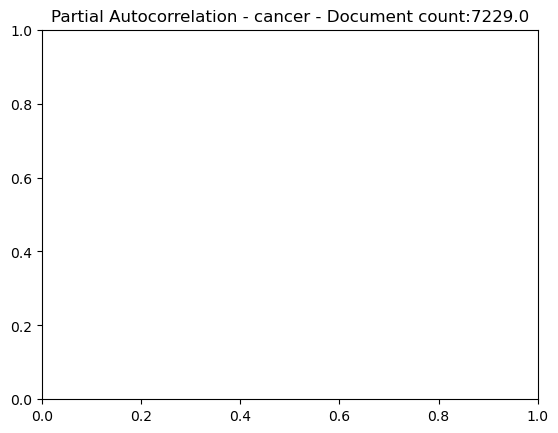

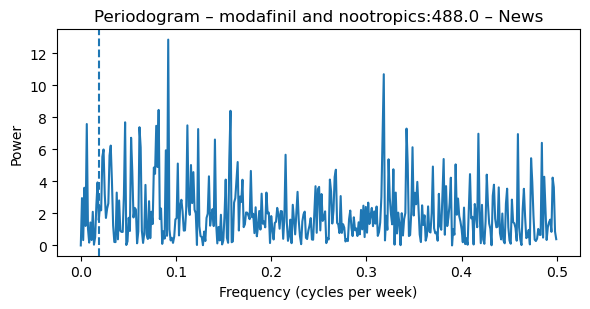

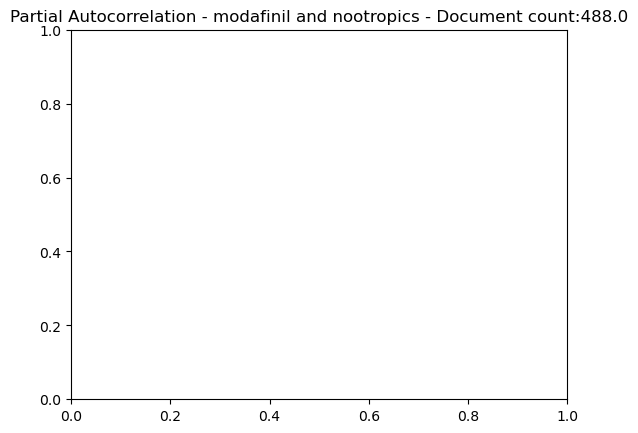

In [22]:
for topic_num in range(17):
    pm_ts = create_ts_per_source(weekly, 'News', topic_num)
    y = pm_ts['count']  # e.g., PubMed counts for a topic
    metrics = periodogram_seasonality(y, period=52, plot=True, title=f"Periodogram – {topic_map[topic_num]}:{pm_ts['count'].sum()} – News")
    plt.title(f"Partial Autocorrelation - {topic_map[topic_num]} - Document count:{pm_ts['count'].sum()}")
    plt.show()

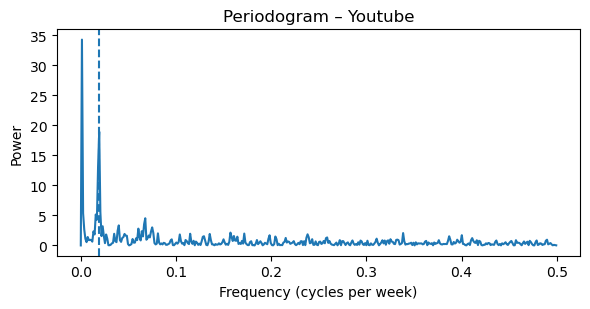

{'annual_share': 0.059121748459514595, 'peak_freq': 0.0012091898428053204, 'peak_weeks': 827.0, 'peak_share': 0.1069966038210591}


In [113]:
y = pm_ts['count']  # e.g., PubMed counts for a topic
metrics = periodogram_seasonality(y, period=52, plot=True, title="Periodogram – Youtube")
print(metrics)

## STL decomposition

In [23]:
from statsmodels.tsa.seasonal import STL

def stl_seasonality(y: pd.Series, period=52, plot=True, title=None):
    """
    y: weekly series (will be regularized to W-MON and zero-filled).
    period: seasonal period in weeks (52 = annual).
    Returns: dict with strength and amplitude.
    """
    y = pd.Series(y).astype(float)
    if isinstance(y.index, (pd.DatetimeIndex, pd.PeriodIndex)):
        y.index = pd.to_datetime(y.index)
        y = y.asfreq("W-MON").fillna(0.0)

    # optional variance stabilization; uncomment if needed
    # y = np.log1p(y)

    stl = STL(y, period=period, robust=True).fit()
    if plot:
        fig = stl.plot()
        if title:
            fig.axes[0].set_title(title)
        plt.tight_layout()
        plt.savefig("./plots/stl_youtube.png")
        plt.show()

    # Seasonality strength (0 = none, 1 = very strong)
    strength = 1 - (stl.resid.var() / (stl.resid + stl.seasonal).var())

    # Simple amplitude estimate (half the seasonal range), and % of mean
    amp = 0.5 * (stl.seasonal.max() - stl.seasonal.min())
    amp_pct = 100 * amp / y.mean() if y.mean() != 0 else np.nan

    return {"strength": float(strength), "amplitude": float(amp), "amplitude_pct": float(amp_pct)}


In [34]:
pm_ts = create_ts_per_source(weekly, 'News', 6)
pm_ts['count'].sum()

np.float64(12850.0)

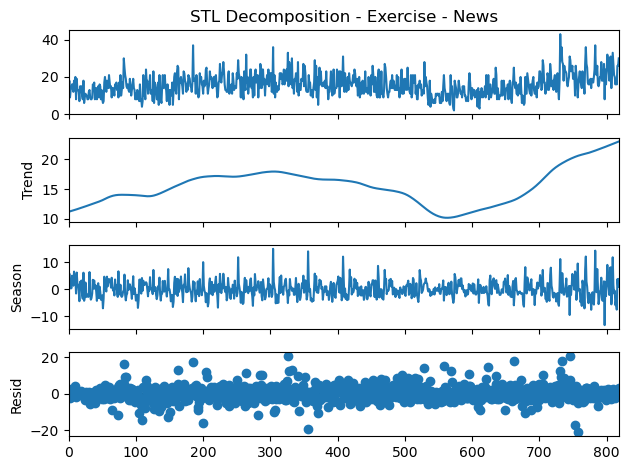

{'strength': 0.2998372324397116, 'amplitude': 14.188985509386965, 'amplitude_pct': 90.43407884971147}


In [36]:
y = pm_ts['count']
metrics = stl_seasonality(y, period=52, plot=True, title="STL Decomposition - Exercise - News")
print(metrics)